# Exploratory Data Analysis (EDA)

## Business Problem Framing
This analysis investigates pricing, availability, and review behavior in NYC Airbnb listings to identify revenue and demand patterns that support decision-ready dashboarding.

## EDA Goals
- Understand data quality, distributions, and segment behavior.
- Identify trends across boroughs, room types, and time.
- Detect outliers that may bias downstream statistical modeling.
- Produce reproducible insights aligned with the capstone rubric.

## Data Loading and Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)

# Resolve either data/processed or data/processes to support naming differences.
project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
processed_candidates = [
    project_root / "data" / "processed" / "Airbnb_Cleaned.csv",
    project_root / "data" / "processes" / "Airbnb_Cleaned.csv",
]

csv_path = next((p for p in processed_candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Airbnb_Cleaned.csv not found in data/processed or data/processes")

df = pd.read_csv(csv_path)
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape}")
df.head()

Loaded: /Users/hardik/DVA-capstone 2/data/processed/Airbnb_Cleaned.csv
Shape: (101803, 25)


,id,host_id,host_name,host_verified,host_listings_count,borough,neighbourhood,lat,long,room_type,construction_year,instant_bookable,cancellation_policy,minimum_nights,availability_365,high_availability,price,service_fee,total_price,price_tier,number_of_reviews,last_review,review_year,reviews_per_month,review_rate
0,1001254,80014485718,Madaline,unconfirmed,6,Brooklyn,Kensington,40.64749,-73.97237,Private room,2020,False,strict,10,286,True,966.0,193.0,1159.0,Luxury,9,2021-10-19,2021,0.21,4
1,1002102,52335172823,Jenna,verified,2,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,2007,False,moderate,30,228,True,142.0,28.0,170.0,Economy,45,2022-05-21,2022,0.38,4
2,1002403,78829239556,Elise,unconfirmed,1,Manhattan,Harlem,40.80902,-73.94190,Private room,2005,True,flexible,3,352,True,620.0,124.0,744.0,Luxury,0,NaT,0,0.00,5
3,1002755,85098326012,Garry,unconfirmed,1,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,2005,True,moderate,30,322,True,368.0,74.0,442.0,Premium,270,2019-07-05,2019,4.64,4
4,1003689,92037596077,Lyndon,verified,1,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,2009,False,moderate,10,289,True,204.0,41.0,245.0,Mid-range,9,2018-11-19,2018,0.10,3


## Missing Data Overview

In [2]:
missing_summary = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .sort_values("missing_pct", ascending=False)
)

display(df.info())
missing_summary.head(15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101803 entries, 0 to 101802
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   id                   101803 non-null  int64         
 1   host_id              101803 non-null  int64         
 2   host_name            101803 non-null  object        
 3   host_verified        101803 non-null  object        
 4   host_listings_count  101803 non-null  int64         
 5   borough              101803 non-null  object        
 6   neighbourhood        101803 non-null  object        
 7   lat                  101803 non-null  float64       
 8   long                 101803 non-null  float64       
 9   room_type            101803 non-null  object        
 10  construction_year    101803 non-null  int64         
 11  instant_bookable     101803 non-null  bool          
 12  cancellation_policy  101803 non-null  object        
 13  minimum_nights

None

,missing_count,missing_pct
last_review,15805,15.53
id,0,0.00
minimum_nights,0,0.00
reviews_per_month,0,0.00
review_year,0,0.00
number_of_reviews,0,0.00
price_tier,0,0.00
total_price,0,0.00
service_fee,0,0.00
price,0,0.00


### Distribution Charts
The following histograms show the distribution of core numeric variables such as price, fees, availability, and reviews.

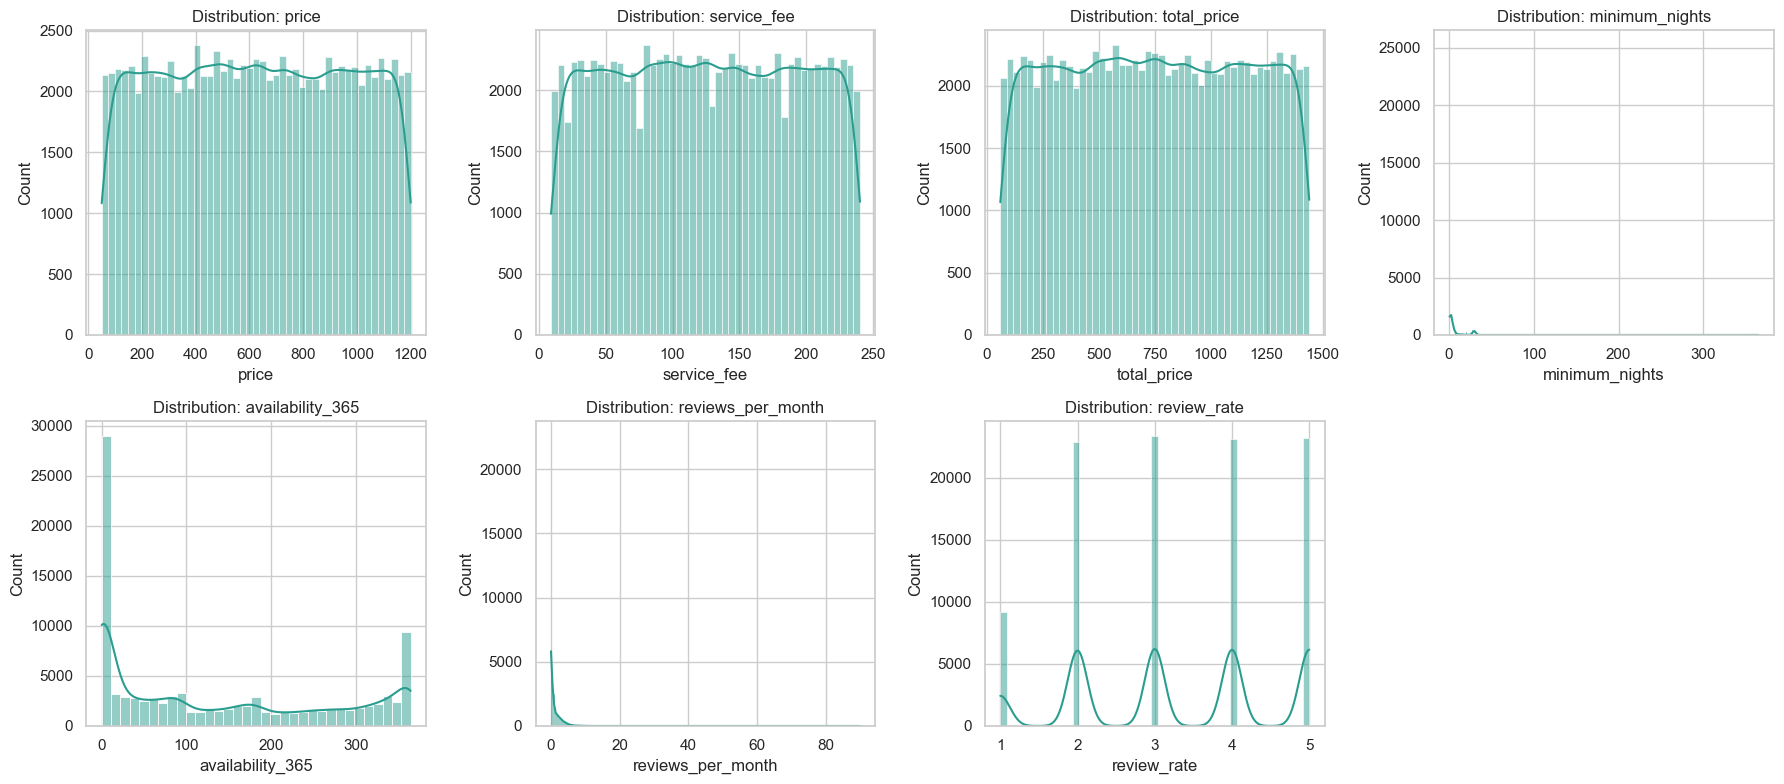

In [3]:
num_cols = ["price", "service_fee", "total_price", "minimum_nights", "availability_365", "reviews_per_month", "review_rate"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#2A9D8F")
    axes[i].set_title(f"Distribution: {col}")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

### Bar Chart and Box Plot
Bar Chart: Listing Volume by Borough
Box Plot: Total Price Distribution by Room Type

/var/folders/b7/m_nr71s115ld7m85whyltltm0000gn/T/ipykernel_59348/770539637.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="borough", order=df["borough"].value_counts().index, palette="Set2")


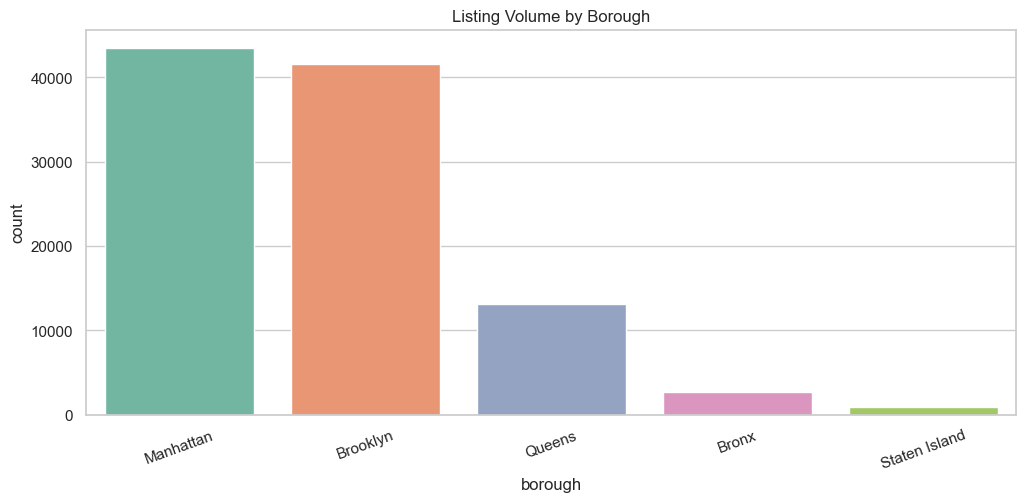

/var/folders/b7/m_nr71s115ld7m85whyltltm0000gn/T/ipykernel_59348/770539637.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="room_type", y="total_price", palette="Set3")


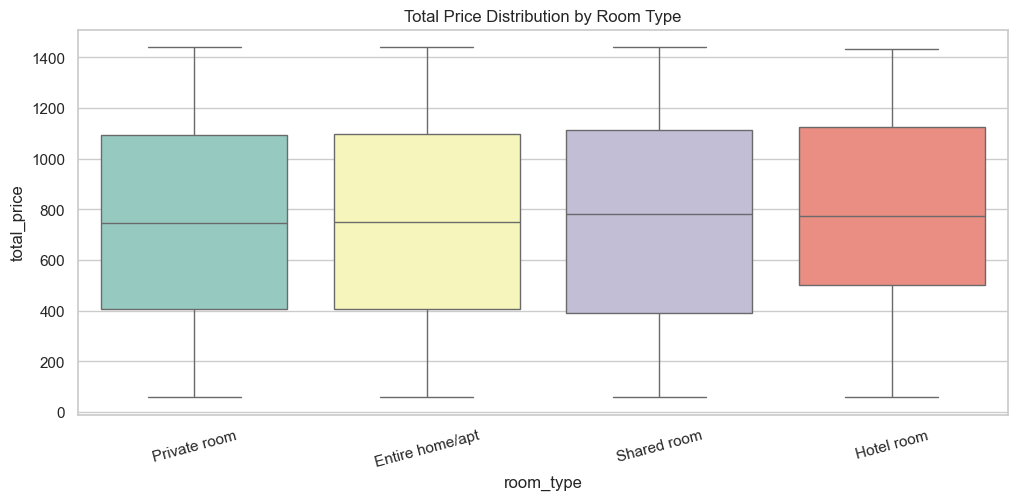

,borough,room_type,listings,median_total_price,avg_review_rate,avg_reviews_per_month
7,Manhattan,Entire home/apt,26268,748.0,3.275011,0.902776
3,Brooklyn,Entire home/apt,20431,751.0,3.248935,1.227057
5,Brooklyn,Private room,20278,749.0,3.263635,1.036813
9,Manhattan,Private room,16212,743.5,3.276832,1.229864
13,Queens,Private room,7691,755.0,3.314133,1.547259
11,Queens,Entire home/apt,5105,750.0,3.350441,1.685877
1,Bronx,Private room,1555,780.0,3.322186,1.365273
0,Bronx,Entire home/apt,1017,736.0,3.347099,1.830511
10,Manhattan,Shared room,892,769.5,3.257848,1.347511
6,Brooklyn,Shared room,819,794.0,3.333333,0.800452


In [4]:
borough_room_summary = (
    df.groupby(["borough", "room_type"], as_index=False)
    .agg(
        listings=("id", "count"),
        median_total_price=("total_price", "median"),
        avg_review_rate=("review_rate", "mean"),
        avg_reviews_per_month=("reviews_per_month", "mean"),
    )
    .sort_values(["listings", "median_total_price"], ascending=[False, False])
)

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="borough", order=df["borough"].value_counts().index, palette="Set2")
plt.title("Listing Volume by Borough")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="room_type", y="total_price", palette="Set3")
plt.title("Total Price Distribution by Room Type")
plt.xticks(rotation=15)
plt.show()

borough_room_summary.head(15)

### Trend Line Chart
Line Chart: Review-Year Trend for listing activity and average price.

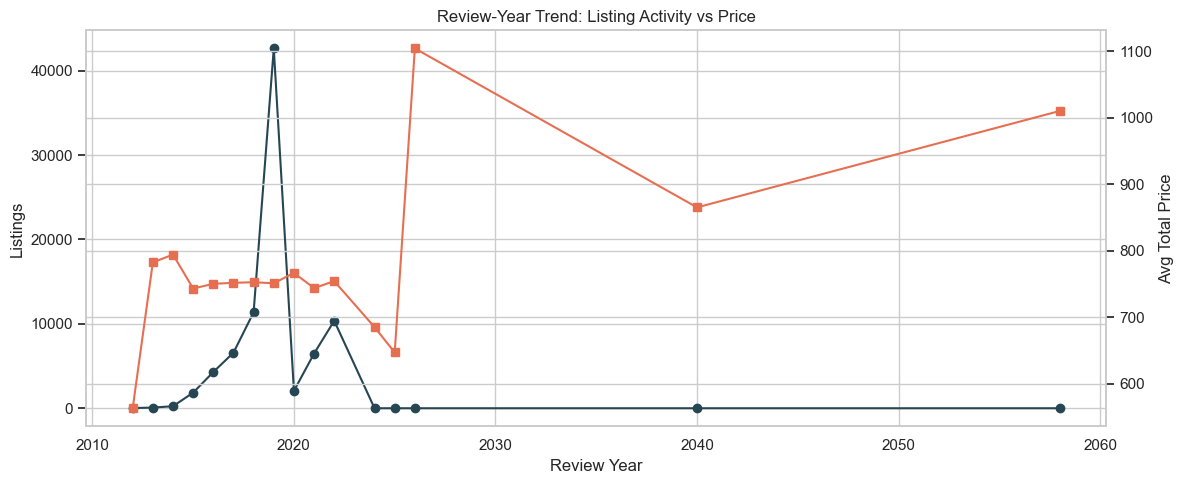

,review_year,listings,avg_total_price,avg_review_rate
6,2018,11372,752.512744,3.223707
7,2019,42636,750.950340,3.269045
8,2020,2063,766.546733,3.481338
9,2021,6485,743.640975,3.492521
10,2022,10366,754.201649,3.497106
11,2024,1,685.000000,4.000000
12,2025,1,647.000000,2.000000
13,2026,1,1104.000000,3.000000
14,2040,1,865.000000,3.000000
15,2058,1,1010.000000,4.000000


In [5]:
yearly_trends = (
    df[df["review_year"] > 0]
    .groupby("review_year", as_index=False)
    .agg(
        listings=("id", "count"),
        avg_total_price=("total_price", "mean"),
        avg_review_rate=("review_rate", "mean"),
    )
    .sort_values("review_year")
)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(yearly_trends["review_year"], yearly_trends["listings"], marker="o", color="#264653", label="Listings")
ax1.set_xlabel("Review Year")
ax1.set_ylabel("Listings")

ax2 = ax1.twinx()
ax2.plot(yearly_trends["review_year"], yearly_trends["avg_total_price"], marker="s", color="#E76F51", label="Avg Total Price")
ax2.set_ylabel("Avg Total Price")

plt.title("Review-Year Trend: Listing Activity vs Price")
fig.tight_layout()
plt.show()

yearly_trends.tail(10)

### Outlier Detection Chart
Box Plot: IQR-based outlier inspection for total price.

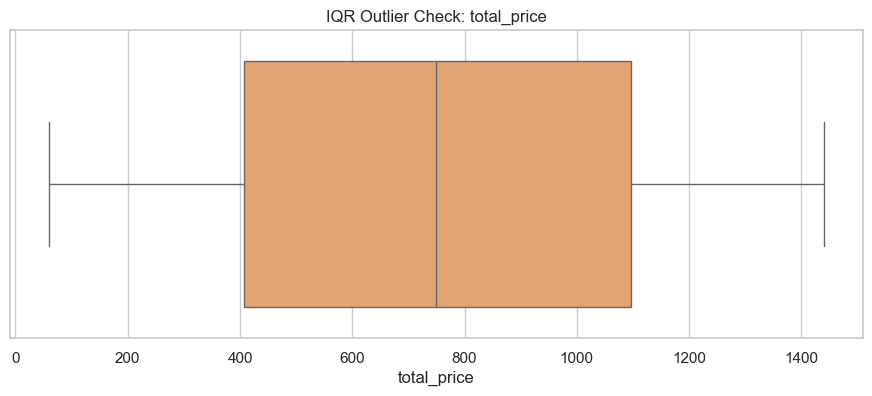

IQR bounds: [-624.00, 2128.00]
Outliers detected: 0 (0.00%)


,id,borough,room_type,total_price,reviews_per_month


In [6]:
q1 = df["total_price"].quantile(0.25)
q3 = df["total_price"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df["total_price"] < lower_bound) | (df["total_price"] > upper_bound)].copy()

plt.figure(figsize=(11, 4))
sns.boxplot(data=df, x="total_price", color="#F4A261")
plt.title("IQR Outlier Check: total_price")
plt.show()

print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
outliers[["id", "borough", "room_type", "total_price", "reviews_per_month"]].head(15)

### Geospatial Scatter Chart
Scatter Plot: Latitude vs Longitude colored by total price bucket.

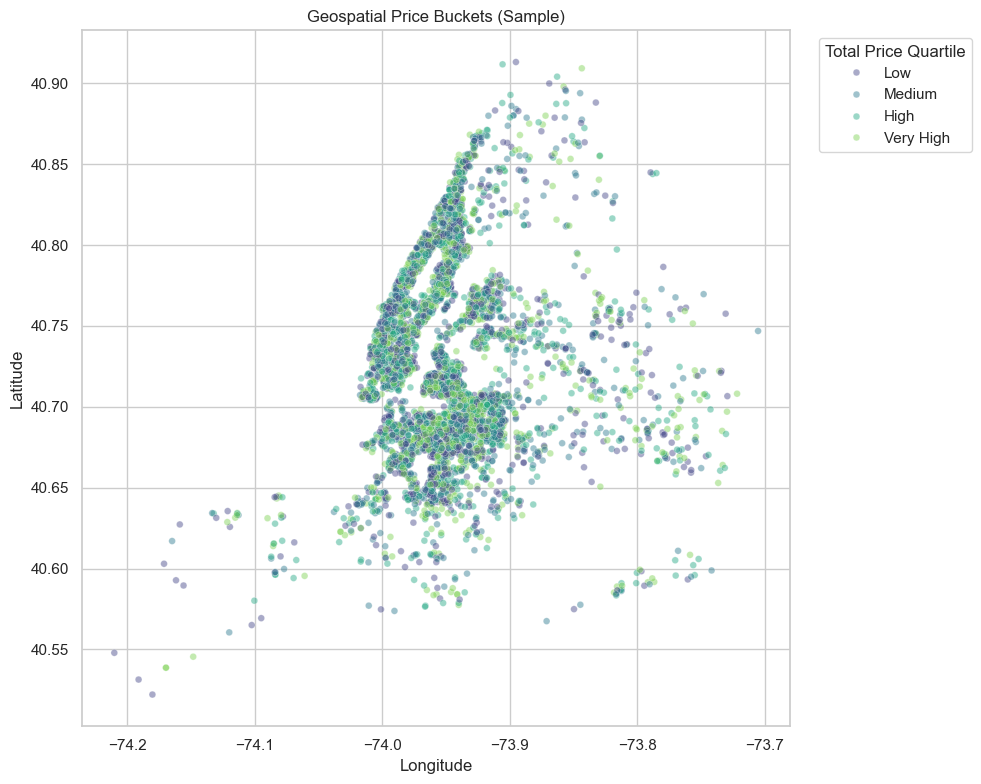

In [7]:
geo_sample = df.sample(n=min(6000, len(df)), random_state=42).copy()
geo_sample["price_bucket"] = pd.qcut(
    geo_sample["total_price"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"],
    duplicates="drop",
)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=geo_sample,
    x="long",
    y="lat",
    hue="price_bucket",
    alpha=0.45,
    s=24,
    palette="viridis",
)
plt.title("Geospatial Price Buckets (Sample)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Total Price Quartile", bbox_to_anchor=(1.03, 1), loc="upper left")
plt.tight_layout()
plt.show()

## KPI Snapshot Table

In [8]:
kpi_snapshot = pd.DataFrame(
    {
        "KPI": [
            "Listings",
            "Median Total Price",
            "Average Total Price",
            "Average Review Rate",
            "Instant Bookable Share",
            "High Availability Share",
            "Outlier Share (Total Price)",
        ],
        "Value": [
            len(df),
            round(df["total_price"].median(), 2),
            round(df["total_price"].mean(), 2),
            round(df["review_rate"].mean(), 2),
            f"{(df['instant_bookable'].astype(str).str.lower().eq('true').mean() * 100):.2f}%",
            f"{(df['high_availability'].astype(str).str.lower().eq('true').mean() * 100):.2f}%",
            f"{(len(outliers)/len(df) * 100):.2f}%",
        ],
    }
)

kpi_snapshot

,KPI,Value
0,Listings,101803
1,Median Total Price,750.0
2,Average Total Price,750.41
3,Average Review Rate,3.28
4,Instant Bookable Share,49.74%
5,High Availability Share,36.11%
6,Outlier Share (Total Price),0.00%


## EDA Insight Summary
- Manhattan and Brooklyn usually dominate listing volume, but room type composition drives price spread.
- `total_price` is right-skewed with a non-trivial outlier segment that should be handled in regression (robust checks/winsorization sensitivity).
- Review-year trends indicate changing listing activity over time; this supports temporal controls in statistical models.
- Geospatial clustering suggests localized price regimes, useful for Tableau map layers and borough-neighborhood drilldowns.

These outputs feed directly into the statistical notebook for formal testing and model-based inference.